# Coordinate Comparison (Screening)

## Setup

In [2]:
import glob, os
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from utilities import utils
from utilities.utils import get_angle, smooth_array, fill_nan
from tasks import cmj, hip, nordic, slr, sls
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

SUBJECT_IDS = [f"P{i:02d}" for i in range(3, 19)]

def _world_path(fp):
    return fp.replace(".txt", "_world.txt")

def _peak_rom(signal):
    s = np.asarray(signal, dtype=float)
    s = s[np.isfinite(s)]
    return float(np.nanmax(s) - np.nanmin(s)) if s.size >= 2 else np.nan

## Angle helpers

- `three_point_angle`: hip-knee-ankle style angle (Nordic, SLS).
- `hip_rotation_angle`: knee->ankle segment vs rest pose (hip ER/IR).
- `slr_angle`: hip-vertex angle vs a vertical reference (SLR).

Each takes `ndims` (2 uses x,y; 3 uses x,y,z) so the same function serves the
2D and 3D methods. **The 3D versions use a provisional definition — flag for
Timi.**

In [3]:
def three_point_angle(fp, joints, ndims, start=0):
    df = cmj.load_pose_file(fp)
    pts = []
    for j in joints:
        xyz = df[[f"{j}_x", f"{j}_y", f"{j}_z"]].to_numpy().copy()
        pts.append(smooth_array(xyz, tuple(range(ndims))))
    a, b, c = [p[start:] for p in pts]
    return get_angle(a, b, c, ndims=ndims)

def hip_rotation_angle(fp, ndims):
    df = cmj.load_pose_file(fp)
    knee = df[["RIGHT_KNEE_x","RIGHT_KNEE_y","RIGHT_KNEE_z"]].to_numpy()[:, :ndims]
    ankle = df[["RIGHT_ANKLE_x","RIGHT_ANKLE_y","RIGHT_ANKLE_z"]].to_numpy()[:, :ndims]
    seg = ankle - knee
    rest = seg[0]
    cos = (seg @ rest) / (np.linalg.norm(seg, axis=1) * np.linalg.norm(rest) + 1e-9)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

def slr_angle(fp, ndims):
    # hip-vertex angle between a vertical reference (from ankle start) and the ankle
    df = cmj.load_pose_file(fp)
    hip_j = df[["RIGHT_HIP_x","RIGHT_HIP_y","RIGHT_HIP_z"]].to_numpy().copy()
    ankle = df[["RIGHT_ANKLE_x","RIGHT_ANKLE_y","RIGHT_ANKLE_z"]].to_numpy().copy()
    hip_j = smooth_array(hip_j, tuple(range(ndims)))
    ankle = smooth_array(ankle, tuple(range(ndims)))
    ankle_ref = np.ones_like(ankle) * ankle[0]
    return get_angle(ankle_ref[:, :ndims], hip_j[:, :ndims], ankle[:, :ndims], ndims=ndims)

## Task configuration

In [4]:
hip_data    = utils.read_list('hip_data')
nordic_data = utils.read_list('nordic_data')
slr_data    = utils.read_list('slr_data')
sls_data    = utils.read_list('sls_data')

def _find_task_file(folder, sid):
    cands = [p for p in glob.glob(f"data/keypoints/{folder}/*.txt")
             if "world" not in p.lower() and sid in os.path.basename(p)]
    return cands[0] if cands else None

TASKS = {
    "Nordic curl": {
        "find_file": lambda sid: _find_task_file("nordic", sid),
        "omc": lambda a: nordic._omc_angle(nordic_data[a],
                     nordic.CODA_START.get(SUBJECT_IDS[a], nordic.CODA_START_DEFAULT)),
        "mmc": lambda fp, nd: three_point_angle(
                     fp, ("RIGHT_HIP","RIGHT_KNEE","RIGHT_ANKLE"), nd, start=600),
        "exclude": set(),
    },
    "Single leg squat": {
        "find_file": lambda sid: _find_task_file("slsq", sid),
        "omc": lambda a: get_angle(
                     fill_nan(sls_data[a]['slsquat']['hip']['coda']),
                     fill_nan(sls_data[a]['slsquat']['knee']['coda']),
                     fill_nan(sls_data[a]['slsquat']['ankle']['coda']), ndims=3),
        "mmc": lambda fp, nd: three_point_angle(
                     fp, ("RIGHT_HIP","RIGHT_KNEE","RIGHT_ANKLE"), nd),
        "exclude": set(),
    },
    "Hip external rotation": {
        "find_file": lambda sid: hip._find_file("data/keypoints/hip", sid, "her"),
        "omc": lambda a: hip._omc_angle(hip_data[a], "her"),
        "mmc": lambda fp, nd: hip_rotation_angle(fp, nd),
        "exclude": {sid for (sid, t) in hip.EXCLUDE if t == "her"},
    },
    "Hip internal rotation": {
        "find_file": lambda sid: hip._find_file("data/keypoints/hip", sid, "hir"),
        "omc": lambda a: hip._omc_angle(hip_data[a], "hir"),
        "mmc": lambda fp, nd: hip_rotation_angle(fp, nd),
        "exclude": {sid for (sid, t) in hip.EXCLUDE if t == "hir"},
    },
    "Straight leg raise": {
        "find_file": lambda sid: _find_task_file("slr", sid),
        "omc": lambda a: slr._omc_angle(slr_data[a], 0),
        "mmc": lambda fp, nd: slr_angle(fp, nd),
        "exclude": slr.EXCLUDE,
    },
}

## Build the comparison table

In [5]:
rows = []
for task_name, cfg in TASKS.items():
    for a, sid in enumerate(SUBJECT_IDS):
        if sid in cfg["exclude"]:
            continue
        normal_fp = cfg["find_file"](sid)
        if not normal_fp:
            continue
        world_fp = _world_path(normal_fp)
        if not os.path.exists(world_fp):
            print(f"[{task_name}] {sid}: no world file, skipped")
            continue
        try:
            omc_rom = _peak_rom(cfg["omc"](a))
            methods = {
                "2D_norm":  cfg["mmc"](normal_fp, 2),
                "3D_norm":  cfg["mmc"](normal_fp, 3),
                "2D_world": cfg["mmc"](world_fp, 2),
                "3D_world": cfg["mmc"](world_fp, 3),
            }
        except Exception as ex:
            print(f"[{task_name}] {sid}: {type(ex).__name__}: {str(ex)[:50]}")
            continue
        for method_name, signal in methods.items():
            rom = _peak_rom(signal)
            rows.append({
                "task": task_name, "subject": sid, "method": method_name,
                "coord_dims": "2D" if method_name.startswith("2D") else "3D",
                "coord_source": "world" if method_name.endswith("world") else "normalized",
                "mmc_rom": np.round(rom, 2), "omc_rom": np.round(omc_rom, 2),
                "error": np.round(abs(rom - omc_rom), 2),
            })

df = pd.DataFrame(rows)
print(df.shape, "rows;", df['task'].nunique(), "tasks")
df.head(8)

(272, 8) rows; 5 tasks


,task,subject,method,coord_dims,coord_source,mmc_rom,omc_rom,error
0,Nordic curl,P03,2D_norm,2D,normalized,95.14,88.99,6.16
1,Nordic curl,P03,3D_norm,3D,normalized,125.59,88.99,36.60
2,Nordic curl,P03,2D_world,2D,world,105.86,88.99,16.87
3,Nordic curl,P03,3D_world,3D,world,107.35,88.99,18.36
4,Nordic curl,P04,2D_norm,2D,normalized,139.21,122.13,17.08
5,Nordic curl,P04,3D_norm,3D,normalized,140.66,122.13,18.54
6,Nordic curl,P04,2D_world,2D,world,125.20,122.13,3.07
7,Nordic curl,P04,3D_world,3D,world,121.36,122.13,0.76


## Save to CSV

In [6]:
os.makedirs("results", exist_ok=True)
df.to_csv("results/coordinate_comparison_screening.csv", index=False)
print("saved results/coordinate_comparison_screening.csv —", len(df), "rows")

saved results/coordinate_comparison_screening.csv — 272 rows


## Analysis

In [7]:
summary = (df.groupby(["task", "method"])["error"]
             .mean().round(2).reset_index()
             .rename(columns={"error": "mean_error"})
             .pivot(index="task", columns="method", values="mean_error"))
summary = summary[["2D_norm","2D_world","3D_norm","3D_world"]]
summary

method,2D_norm,2D_world,3D_norm,3D_world
task,,,,
Hip external rotation,22.38,15.97,38.71,18.34
Hip internal rotation,10.01,8.79,23.62,10.75
Nordic curl,21.94,17.77,30.15,17.66
Single leg squat,43.28,4.50,48.80,4.51
Straight leg raise,18.21,24.87,28.35,24.47


In [8]:
for task_name in df["task"].unique():
    sub = df[df["task"] == task_name]
    grid = sub.pivot_table(index="coord_dims", columns="coord_source",
                           values="error", aggfunc="mean").round(2)
    print(f"\n{task_name}  (mean peak-ROM error vs OMC, lower = better)")
    print(grid)


Nordic curl  (mean peak-ROM error vs OMC, lower = better)
coord_source  normalized  world
coord_dims                     
2D                 21.94  17.77
3D                 30.15  17.66

Single leg squat  (mean peak-ROM error vs OMC, lower = better)
coord_source  normalized  world
coord_dims                     
2D                 43.28   4.50
3D                 48.80   4.51

Hip external rotation  (mean peak-ROM error vs OMC, lower = better)
coord_source  normalized  world
coord_dims                     
2D                 22.38  15.97
3D                 38.71  18.34

Hip internal rotation  (mean peak-ROM error vs OMC, lower = better)
coord_source  normalized  world
coord_dims                     
2D                 10.01   8.79
3D                 23.62  10.75

Straight leg raise  (mean peak-ROM error vs OMC, lower = better)
coord_source  normalized  world
coord_dims                     
2D                 18.21  24.87
3D                 28.35  24.47


In [9]:
# best method per task
print("Best coordinate method per task (screening):\n")
for task_name in df["task"].unique():
    sub = df[df["task"] == task_name]
    means = sub.groupby("method")["error"].mean()
    best = means.idxmin()
    print(f"  {task_name:26} current 2D_norm={means['2D_norm']:.2f}  best={best} ({means[best]:.2f})")

Best coordinate method per task (screening):

  Nordic curl                current 2D_norm=21.94  best=3D_world (17.66)
  Single leg squat           current 2D_norm=43.28  best=2D_world (4.50)
  Hip external rotation      current 2D_norm=22.38  best=2D_world (15.97)
  Hip internal rotation      current 2D_norm=10.01  best=2D_world (8.79)
  Straight leg raise         current 2D_norm=18.21  best=2D_norm (18.21)


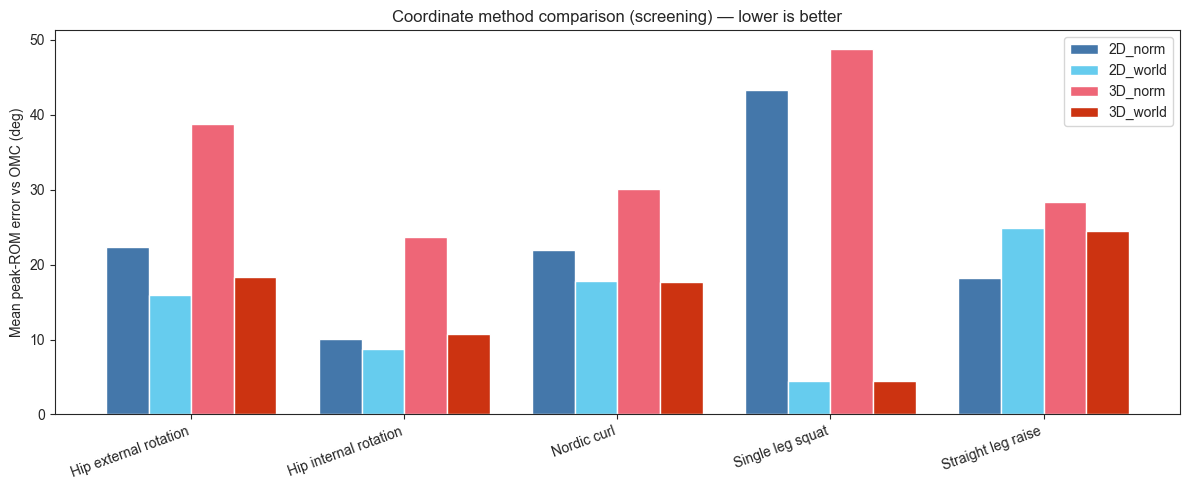

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# pivot: tasks as rows, methods as columns
pivot = (df.groupby(["task","method"])["error"].mean()
           .unstack()[["2D_norm","2D_world","3D_norm","3D_world"]])

tasks = pivot.index.tolist()
methods = ["2D_norm","2D_world","3D_norm","3D_world"]
colors = ["#4477AA","#66CCEE","#EE6677","#CC3311"]  # blue-ish = norm, red-ish = world? 
# actually pair by source: make world bars distinct
x = np.arange(len(tasks)); w = 0.2

fig, ax = plt.subplots(figsize=(12,5))
for i, m in enumerate(methods):
    ax.bar(x + i*w, pivot[m], w, label=m, color=colors[i])
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(tasks, rotation=20, ha='right')
ax.set_ylabel("Mean peak-ROM error vs OMC (deg)")
ax.set_title("Coordinate method comparison (screening) — lower is better")
ax.legend()
plt.tight_layout()
plt.savefig("results/coord_comparison_bars.png", dpi=150, bbox_inches='tight')
plt.show()

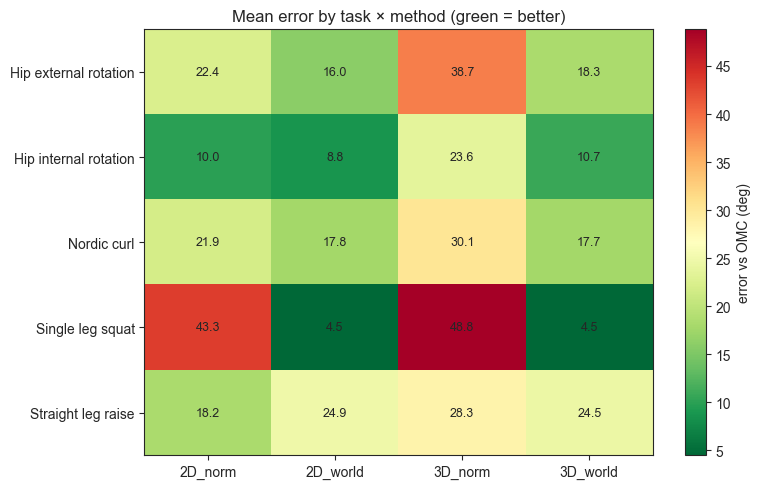

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods)
ax.set_yticks(range(len(tasks))); ax.set_yticklabels(tasks)
# annotate each cell with the number
for i in range(len(tasks)):
    for j in range(len(methods)):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Mean error by task × method (green = better)")
fig.colorbar(im, label="error vs OMC (deg)")
plt.tight_layout()
plt.savefig("results/coord_comparison_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import inspect
from tasks import hip, nordic, slr

# for tasks that call a module's _omc_angle, check that function's ndims
print("=== hip._omc_angle ===")
print(inspect.getsource(hip._omc_angle))
print("=== nordic._omc_angle ===")
print(inspect.getsource(nordic._omc_angle))
print("=== slr._omc_angle ===")
print(inspect.getsource(slr._omc_angle))

=== hip._omc_angle ===
def _omc_angle(p, task):
    knee = p[task]['knee']['coda'][:, [1, 2]]
    ankle = p[task]['ankle']['coda'][:, [1, 2]]
    knee_ref = np.ones_like(knee) * knee[0]
    ankle_ref = np.ones_like(ankle) * ankle[0]
    return intersection_angle(line1=[ankle_ref, knee_ref], line2=[ankle, knee])

=== nordic._omc_angle ===
def _omc_angle(p, start):
    """hip-knee-ankle angle from the pickle OMC 'coda' (ndims=3)."""
    hip = fill_nan(p['nordic']['hip']['coda'])[start:]
    knee = fill_nan(p['nordic']['knee']['coda'])[start:]
    ankle = fill_nan(p['nordic']['ankle']['coda'])[start:]
    return get_angle(hip, knee, ankle, ndims=3)

=== slr._omc_angle ===
def _omc_angle(p, omc_start):
    hip = smooth_array(p['hip']['coda'].copy(), [0, 1, 2])
    ankle = smooth_array(p['ankle']['coda'].copy(), [0, 1, 2])
    ankle_ref = np.ones_like(ankle) * ankle[0]           
    ang = get_angle(ankle_ref, hip, ankle, ndims=3)  
    return savgol_filter(ang, 21, 2)[omc_start:]



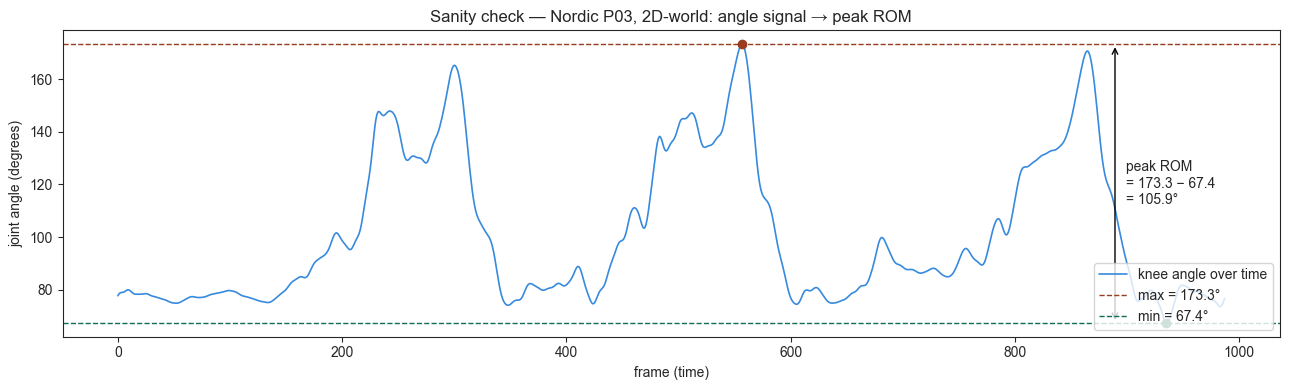

max angle: 173.3°
min angle: 67.4°
peak ROM = max - min = 105.9°


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tasks import cmj, hip, nordic
from utilities.utils import get_angle, smooth_array
from utilities import utils

# --- pick one subject + task to sanity-check (Nordic P03, 2D-world) ---
sid = "P03"
import glob, os
normal_fp = next(p for p in glob.glob("data/keypoints/nordic/*.txt")
                 if "world" not in p.lower() and sid in os.path.basename(p))
world_fp = normal_fp.replace(".txt", "_world.txt")

def nordic_angle(fp, ndims):
    df = cmj.load_pose_file(fp)
    pts = []
    for j in ("RIGHT_HIP","RIGHT_KNEE","RIGHT_ANKLE"):
        xyz = df[[f"{j}_x", f"{j}_y", f"{j}_z"]].to_numpy().copy()
        pts.append(smooth_array(xyz, tuple(range(ndims))))
    hip_, knee, ankle = [p[600:] for p in pts]   # MMC_START
    return get_angle(hip_, knee, ankle, ndims=ndims)

# compute the angle signal for one method
signal = nordic_angle(world_fp, 2)   # 2D-world
signal = signal[np.isfinite(signal)]

peak = np.nanmax(signal)
trough = np.nanmin(signal)
rom = peak - trough

# --- plot: the signal, with max/min marked and ROM annotated ---
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(signal, color="#378ADD", lw=1.2, label="knee angle over time")
ax.axhline(peak, color="#993C1D", ls="--", lw=1, label=f"max = {peak:.1f}°")
ax.axhline(trough, color="#0F6E56", ls="--", lw=1, label=f"min = {trough:.1f}°")

# mark the actual max/min points
imax, imin = np.argmax(signal), np.argmin(signal)
ax.plot(imax, peak, "o", color="#993C1D")
ax.plot(imin, trough, "o", color="#0F6E56")

# annotate ROM as the vertical gap
ax.annotate("", xy=(len(signal)*0.9, peak), xytext=(len(signal)*0.9, trough),
            arrowprops=dict(arrowstyle="<->", color="black"))
ax.text(len(signal)*0.91, (peak+trough)/2,
        f"peak ROM\n= {peak:.1f} − {trough:.1f}\n= {rom:.1f}°",
        va="center", fontsize=10)

ax.set_xlabel("frame (time)")
ax.set_ylabel("joint angle (degrees)")
ax.set_title(f"Sanity check — Nordic {sid}, 2D-world: angle signal → peak ROM")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/rom_sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"max angle: {peak:.1f}°")
print(f"min angle: {trough:.1f}°")
print(f"peak ROM = max - min = {rom:.1f}°")